In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

import healpy as hp

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
min_nobs = 2
max_ebv = 0.15
max_stardens = 2500

--------
## Area and target density

In [4]:
randoms_density = 2500

randoms_columns = ['RA', 'DEC', 'NOBS_G', 'NOBS_R', 'NOBS_Z', 'MASKBITS', 'PHOTSYS', 'EBV']
randoms = Table(fitsio.read('/global/cfs/cdirs/desi/target/catalogs/dr9/0.49.0/randoms/resolve/randoms-1-0.fits', columns=randoms_columns))
lrgmask = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/desi_mask/randoms/lrgmask_v1.1/randoms-1-0-lrgmask_v1.1.fits.gz'))
randoms = hstack([randoms, lrgmask], join_type='exact')

mask = (randoms['NOBS_G']>=min_nobs) & (randoms['NOBS_R']>=min_nobs) & (randoms['NOBS_Z']>=min_nobs)
print('NOBS', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
randoms = randoms[mask]

mask = randoms['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
randoms = randoms[mask]

# Martin's EBV cut
mask = randoms['EBV']<max_ebv
print('EBV', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
randoms = randoms[mask]

# Martin's STARDENS cut
stardens = np.load('/global/cfs/cdirs/desi/users/rongpu/useful/healpix_maps/pixweight-dr7.1-0.22.0_stardens_64_ring.npy')
stardens_nside = 64
mask = stardens>=max_stardens
bad_hp_idx = np.arange(len(stardens))[mask]
cat_hp_idx = hp.pixelfunc.ang2pix(stardens_nside, randoms['RA'], randoms['DEC'], lonlat=True, nest=False)
mask_bad = np.in1d(cat_hp_idx, bad_hp_idx)
print('STARDENS', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
randoms = randoms[~mask_bad]

# Remove DEC<-29
mask = randoms['DEC']>-29
print('DEC>-29', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
randoms = randoms[mask]

print(len(randoms))

area = len(randoms)/randoms_density
area_north = np.sum(randoms['PHOTSYS']=='N')/randoms_density
area_south = np.sum(randoms['PHOTSYS']=='S')/randoms_density
print('Area:', area)
print('Area (north):', area_north)
print('Area (south):', area_south)

NOBS 47030705 4707911 0.9090058574431137
LRG mask 43072114 3958591 0.9158296478864181
EBV 42566665 505449 0.011734947581165856
STARDENS 41640625 926040 0.021755051752351283
DEC>-29 34290394 7350231 0.17651586641651032
34290394
Area: 13716.1576
Area (north): 4212.9204
Area (south): 9503.2372


---------
## Number of LRG targets and the average QSO fraction in the LRG targets

In [6]:
main_dir = '/global/cfs/cdirs/desi/users/rongpu/targets/dr9.0/1.1.1/resolve'
tmp = Table(fitsio.read(os.path.join(main_dir, 'dr9_lrg_1.1.1_basic.fits')))
tmp1 = Table(fitsio.read(os.path.join(main_dir, 'dr9_lrg_1.1.1_photom.fits'), columns=['EBV']))
tmp2 = Table(fitsio.read(os.path.join(main_dir, 'dr9_lrg_1.1.1_lrgmask_v1.1.fits.gz')))
tmp3 = Table(fitsio.read(os.path.join(main_dir, 'dr9_lrg_1.1.1_pixel.fits')))
tmp4 = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/lrg_xcorr/catalogs/dr9_lrg_1.1.1_pzbins_20221204.fits', columns=['pz_bin']))
cat = hstack([tmp, tmp1, tmp2, tmp3, tmp4])

In [7]:
mask = (cat['PIXEL_NOBS_G']>=min_nobs) & (cat['PIXEL_NOBS_R']>=min_nobs) & (cat['PIXEL_NOBS_Z']>=min_nobs)
print('NOBS', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
cat = cat[mask]

mask = cat['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
cat = cat[mask]

# Martin's EBV cut
mask = cat['EBV']<max_ebv
print('EBV', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Martin's STARDENS cut
stardens = np.load('/global/cfs/cdirs/desi/users/rongpu/useful/healpix_maps/pixweight-dr7.1-0.22.0_stardens_64_ring.npy')
stardens_nside = 64
mask = stardens>=max_stardens
bad_hp_idx = np.arange(len(stardens))[mask]
cat_hp_idx = hp.pixelfunc.ang2pix(stardens_nside, cat['RA'], cat['DEC'], lonlat=True, nest=False)
mask_bad = np.in1d(cat_hp_idx, bad_hp_idx)
print('STARDENS', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
cat = cat[~mask_bad]

# Remove DEC<-29
mask = cat['DEC']>-29
print('DEC>-29', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

print('# LRG targets:', len(cat))
print('# LRG targets (north):', np.sum(cat['PHOTSYS']=='N'))
print('# LRG targets (north):', np.sum(cat['PHOTSYS']=='S'))

NOBS 11687649 651341 0.9472127783554407
LRG mask 10312938 1374711 0.8823791679575593
EBV 10183143 129795 0.012585647271417708
STARDENS 9953765 229378 0.022525265529512842
DEC>-29 8259603 1694162 0.17020313419093178
# LRG targets: 8259603
# LRG targets (north): 2542245
# LRG targets (north): 5717358


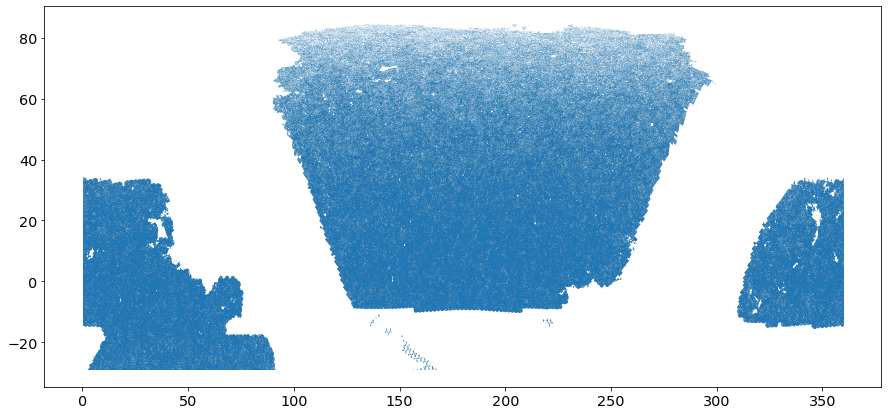

In [8]:
plt.figure(figsize=(15, 7))
plt.plot(cat['RA'], cat['DEC'], '.', ms=0.1, alpha=0.2)
plt.show()

In [9]:
mask_north = cat['PHOTSYS']=='N'
mask_south = cat['PHOTSYS']=='S'

In [10]:
densities = {}

mask = mask_south.copy()
densities['all_south'] = np.sum(mask)/area_south

mask = mask_north.copy()
densities['all_north'] = np.sum(mask)/area_north

for pz_bin in range(1, 5):
    mask = mask_south & (cat['pz_bin']==pz_bin)
    densities['bin_{}_south'.format(pz_bin)] = np.sum(mask)/area_south
    mask = mask_north & (cat['pz_bin']==pz_bin)
    densities['bin_{}_north'.format(pz_bin)] = np.sum(mask)/area_north

densities

{'all_south': 601.6221503973404,
 'all_north': 603.4400744908448,
 'bin_1_south': 80.85066002561737,
 'bin_1_north': 83.27050280845563,
 'bin_2_south': 147.66020993351614,
 'bin_2_north': 149.34818137081345,
 'bin_3_south': 163.3810634548825,
 'bin_3_north': 163.70449344355046,
 'bin_4_south': 149.1765353389264,
 'bin_4_north': 150.19367562700685}

In [11]:
# QSO overlap
mask_qso = cat['DESI_TARGET'] & 2**2>0
print('QSO overlap: {:.3f}%'.format(np.sum(mask_qso)/len(cat)*100))
print('QSO overlap (north): {:.3f}%'.format(np.sum(mask_qso & mask_north)/np.sum(mask_north)*100))
print('QSO overlap (south): {:.3f}%'.format(np.sum(mask_qso & mask_south)/np.sum(mask_south)*100))

QSO overlap: 0.608%
QSO overlap (north): 0.551%
QSO overlap (south): 0.633%


In [12]:
qso_frac_dict = {}

for photsys in ['S', 'N']:
    for bin_index in range(1, 5):
        mask0 = cat['PHOTSYS']==photsys
        mask0 &= cat['pz_bin']==bin_index
        mask_qso = cat['DESI_TARGET'] & 2**2>0
        qso_frac = np.sum(mask_qso & mask0) / np.sum(mask0)
        qso_frac_dict[photsys+str(bin_index)] = qso_frac
        # print(photsys+str(bin_index), '{:.3f}%'.format(100*qso_frac))

qso_frac_dict

{'S1': 0.002601702624999512,
 'S2': 0.0059476215927311595,
 'S3': 0.00792130095082662,
 'S4': 0.003327314024519278,
 'N1': 0.002813472743235693,
 'N2': 0.005089066612417196,
 'N3': 0.006120282916276386,
 'N4': 0.003312503753433404}